# 05 - Machine Learning

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = BASE_DIR / "src"
sys.path.insert(0, str(SRC_DIR))

DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"
REPORTS = BASE_DIR / "reports"
FIGURES = REPORTS / "figures"
MODELS = BASE_DIR / "models"

print("Project:", BASE_DIR)
print("Artifacts present:", REPORTS.exists(), FIGURES.exists(), MODELS.exists())

Project: C:\Users\Province Settat\Desktop\ML\project
Artifacts present: True True True


Load saved model metrics and compare the classical ML models.

In [2]:
metrics_path = REPORTS / "NR_AhR_morgan_metrics.json"
with open(metrics_path) as f:
    metrics = json.load(f)
rows = []
for model, vals in metrics.items():
    rows.append({k: vals.get(k) for k in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]} | {"model": model})
ml = pd.DataFrame(rows).sort_values("roc_auc", ascending=False)
display(ml)
print("Best ROC-AUC:", ml.iloc[0]["model"], ml.iloc[0]["roc_auc"])

,accuracy,precision,recall,f1,roc_auc,pr_auc,model
5,0.890756,0.528497,0.662338,0.587896,0.911227,0.603250,SVM
2,0.913675,0.753086,0.396104,0.519149,0.909172,0.635087,RandomForest
3,0.892284,0.809524,0.110390,0.194286,0.893166,0.614391,XGBoost
4,0.849503,0.420664,0.740260,0.536471,0.887002,0.617363,LightGBM
0,0.857907,0.433884,0.681818,0.530303,0.878760,0.570580,LogisticRegression
1,0.750191,0.284289,0.740260,0.410811,0.801650,0.328508,DecisionTree


Best ROC-AUC: SVM 0.9112273008376903


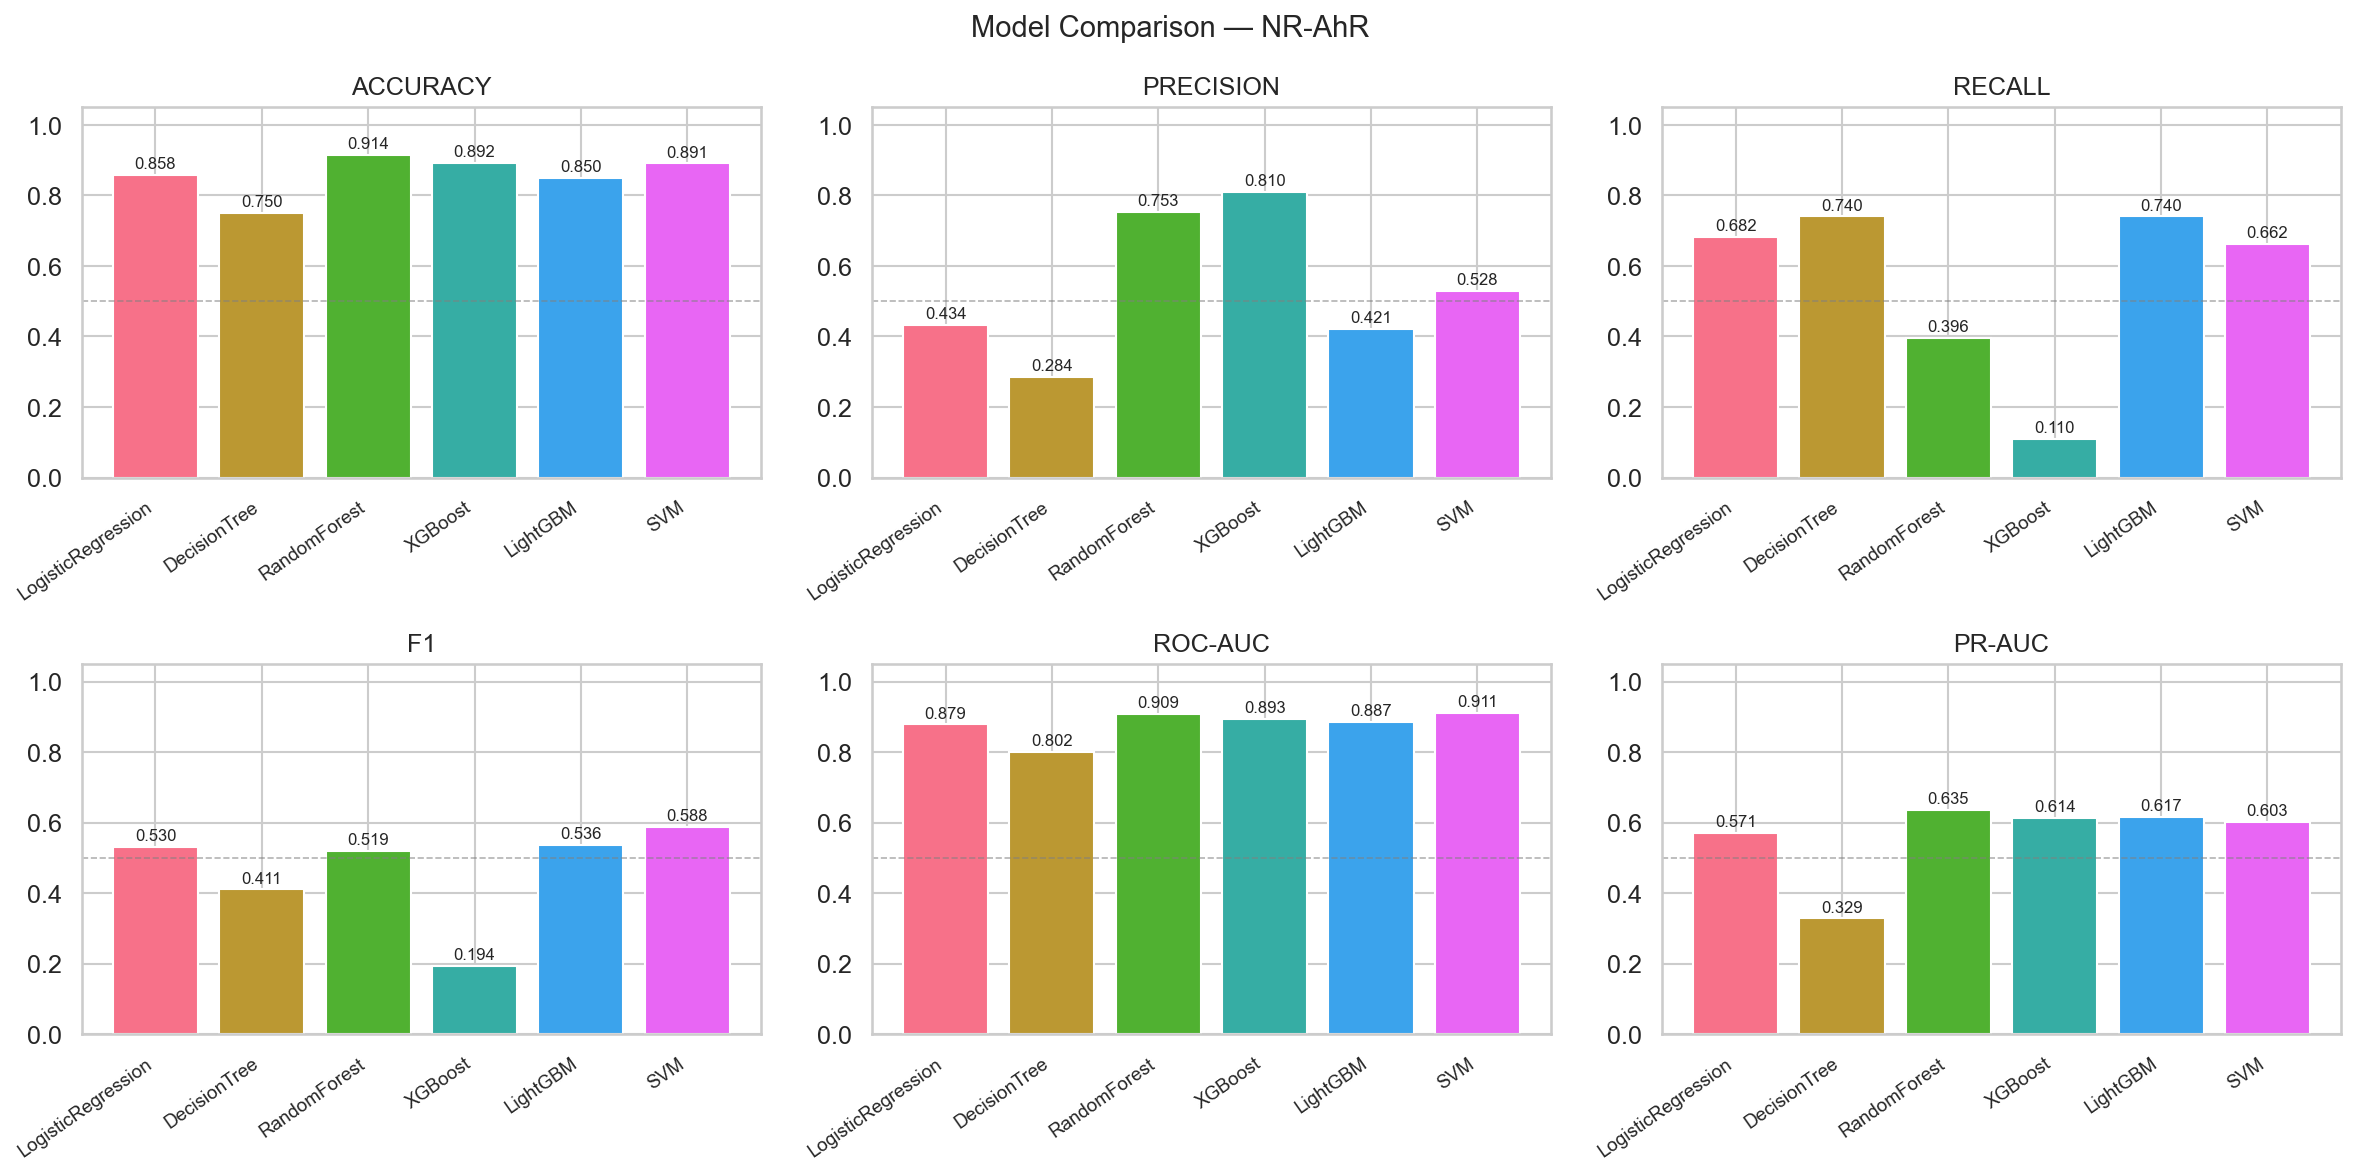

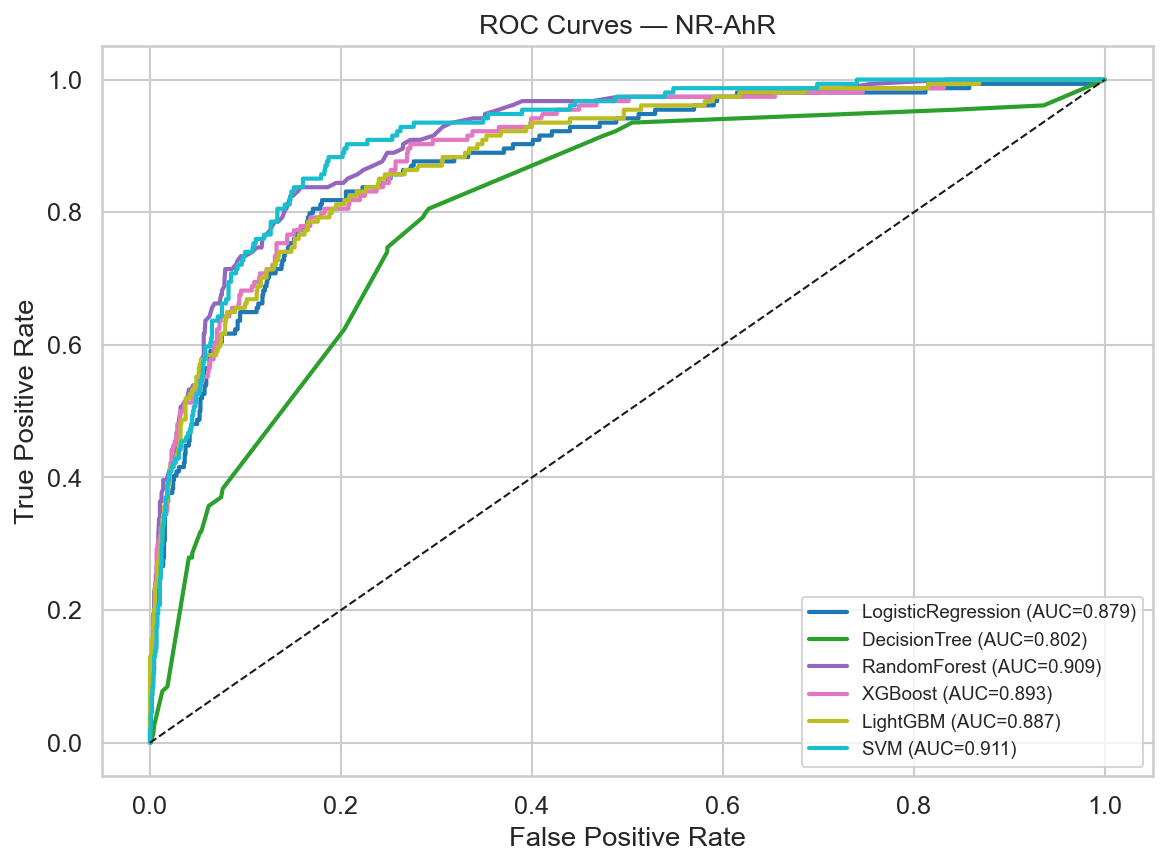

In [3]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "model_comparison_NR_AhR.png")))
display(Image(filename=str(FIGURES / "roc_curves_NR_AhR.png")))